In [125]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [126]:
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [128]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

KeyError: 'timestamp'

In [129]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(50)
large_buy_orders.head(5)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320


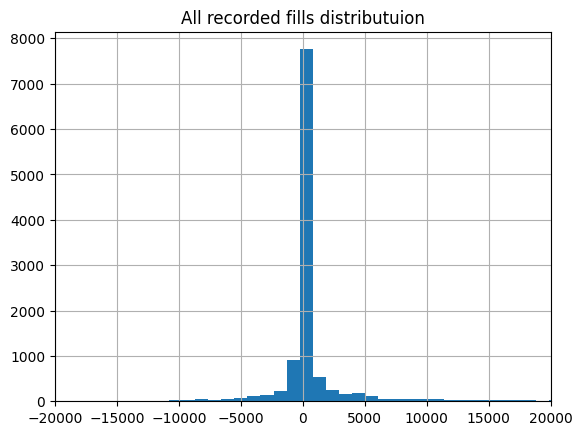

count     11271.000000
mean        461.382575
std        5229.972310
min     -270000.000000
25%         -45.000000
50%          11.000000
75%         232.000000
max      153143.000000
Name: volume, dtype: float64

In [83]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [88]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [95]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,31655,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [110]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,31655,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [139]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
8,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
49,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
1,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
0,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
40,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.77,8.78,8.775


In [141]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
2,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355
3,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040
4,2026-03-27 11:12:23+00:00,SR310CD6,37505,9,310,2026-03-27 11:12:57+00:00,9.46,9.80,9.630


In [174]:
horizons = [5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,best_bid_10080,mid_5,mid_30,mid_60,mid_120,mid_480,mid_720,mid_1440,mid_4320,mid_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,NaN,8.805,8.590,8.220,8.045,7.235,7.665,NaN,NaN,NaN
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340,2026-04-01 11:46:14+00:00,...,8.93,NaN,12.135,12.140,11.795,11.895,NaN,11.125,NaN,9.515
2,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355,2026-04-02 15:34:40+00:00,...,0.43,4.515,4.355,4.640,4.395,NaN,NaN,5.615,NaN,4.215
3,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040,2026-04-03 09:22:28+00:00,...,47.01,47.230,46.710,46.600,47.060,46.130,46.020,NaN,46.54,47.180
4,2026-03-27 11:12:23+00:00,SR310CD6,37505,9,310,2026-03-27 11:12:57+00:00,9.46,9.80,9.630,2026-04-03 11:12:57+00:00,...,8.21,NaN,NaN,9.855,9.210,8.640,NaN,NaN,9.12,8.540


In [178]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

In [181]:
snr = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'] 
    mean = returns.mean()
    std = returns.std()
    snr.append(mean/std)

Text(0, 0.5, 'snr')

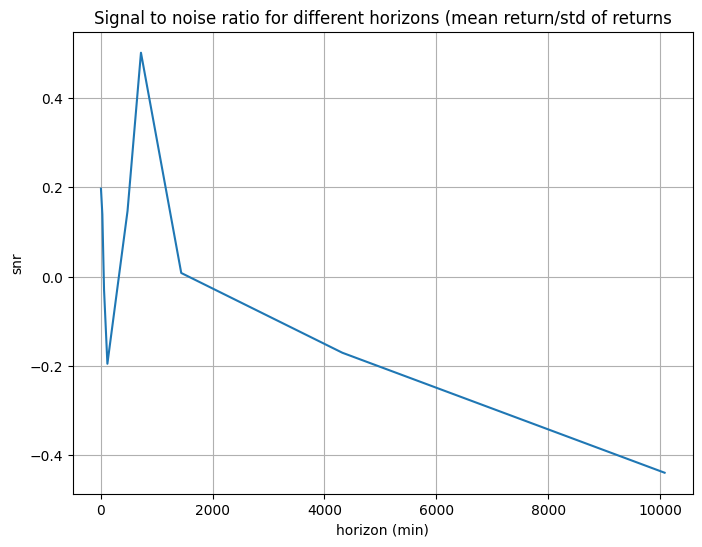

In [189]:
fig = plt.figure(figsize=(8,6))
plt.plot(horizons, snr)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns")
plt.xlabel("horizon (min)")
plt.ylabel("snr")